
CUSTOMER SEGMENTATION USING K-MEANS

Dataset loaded successfully.
Dataset shape: (200, 5)

First five rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Column names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non

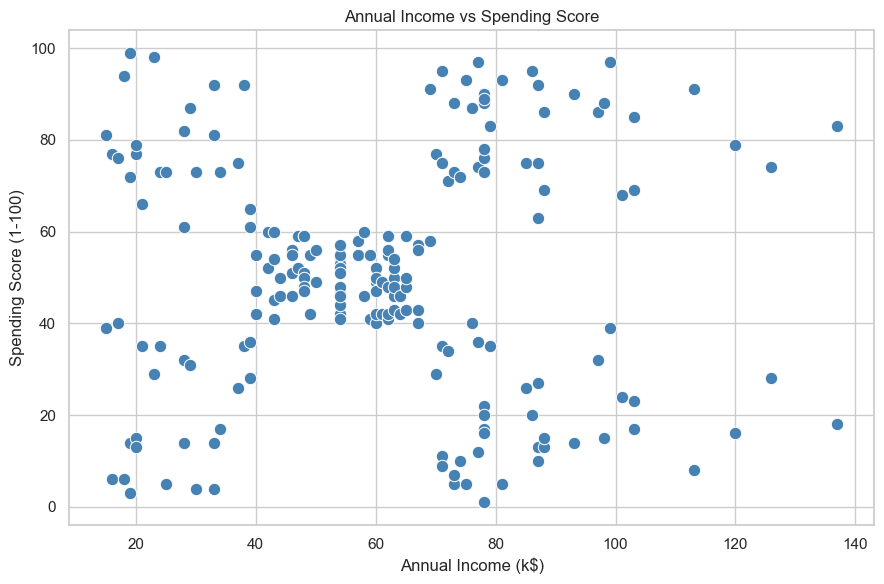

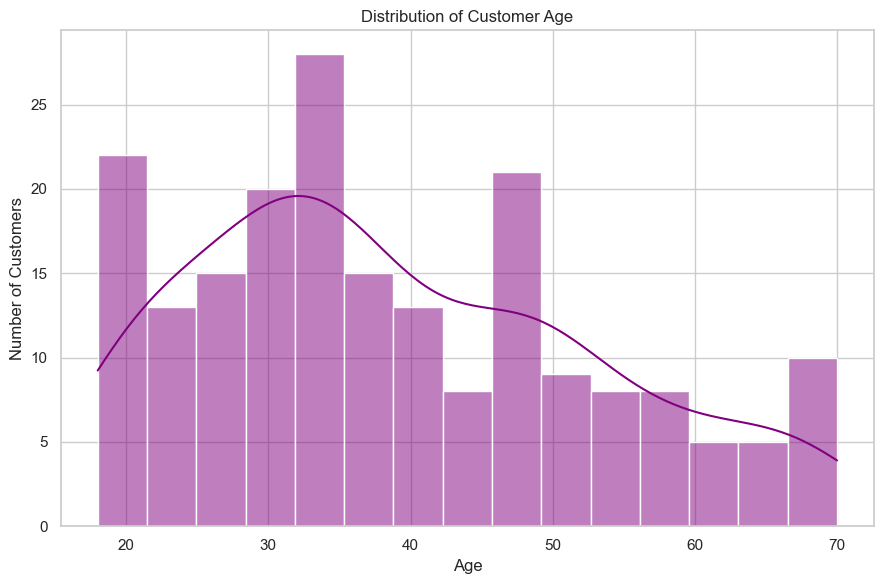

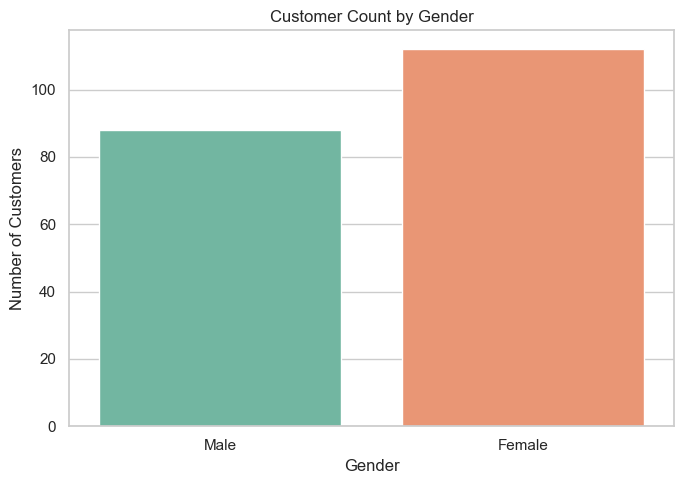

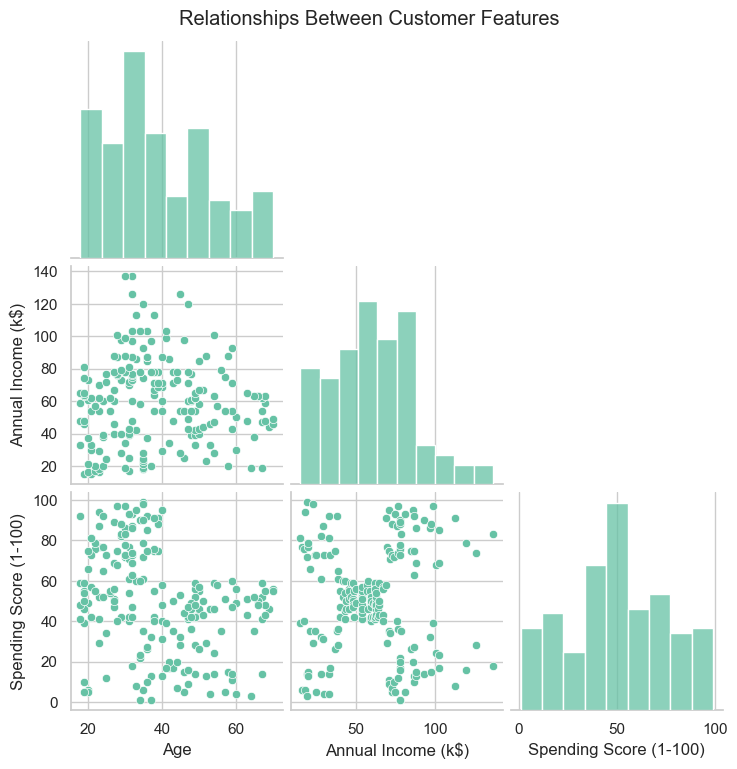


FEATURE SCALING

Features were standardized using StandardScaler.
This is important because K-Means uses distance calculations.

SELECTING THE NUMBER OF CLUSTERS

Cluster evaluation results:
   Number of Clusters (k)   Inertia  Silhouette Score
0                       2  389.3862            0.3355
1                       3  295.2122            0.3578
2                       4  205.2251            0.4040
3                       5  168.2476            0.4166
4                       6  133.8684            0.4284
5                       7  117.0116            0.4172
6                       8  103.8733            0.4082


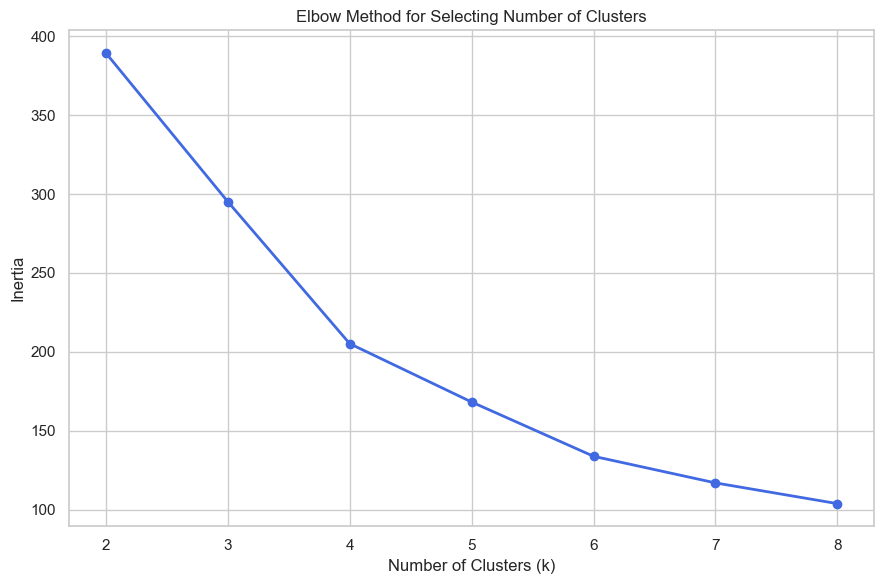

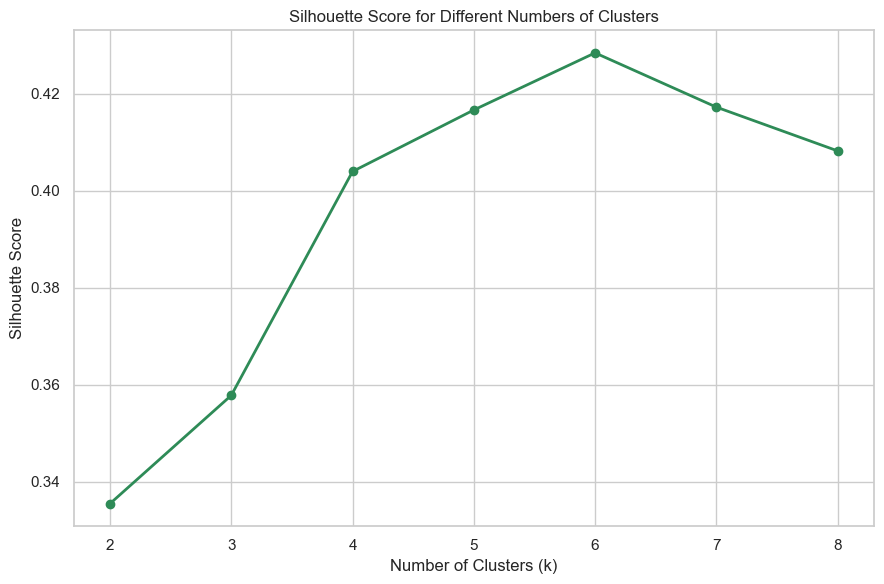


Best k based on silhouette score: 6
Best silhouette score: 0.4284

FINAL K-MEANS MODEL

Customers assigned to clusters successfully.

Number of customers in each cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

CLUSTER PROFILE ANALYSIS

Average values by cluster:
           Age  Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                                   
0        56.33               54.27                   49.07              45
1        26.79               57.10                   48.13              39
2        41.94               88.94                   16.97              33
3        32.69               86.54                   82.13              39
4        25.00               25.26                   77.61              23
5        45.52               26.29                   19.38              21

Cluster names and interpretations:
           Age  Annual Income (k$)  Spending Score (1-10

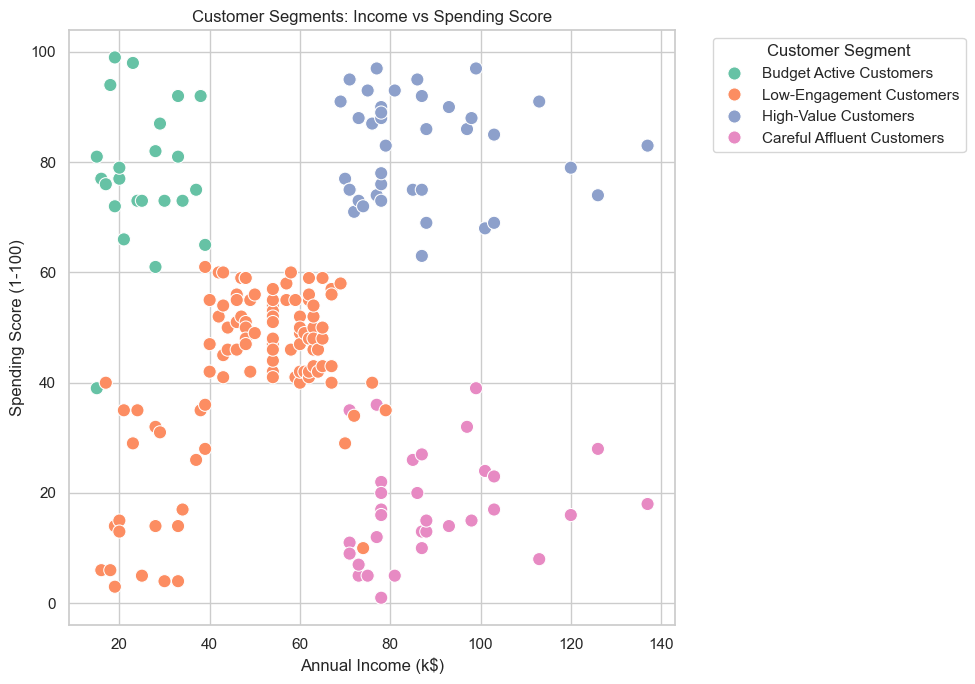

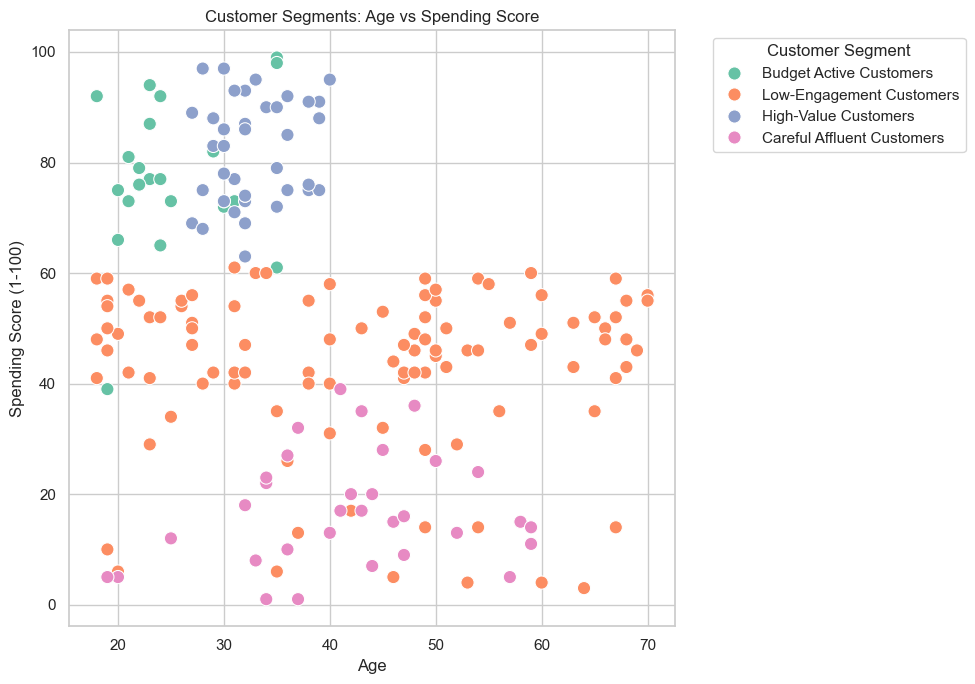

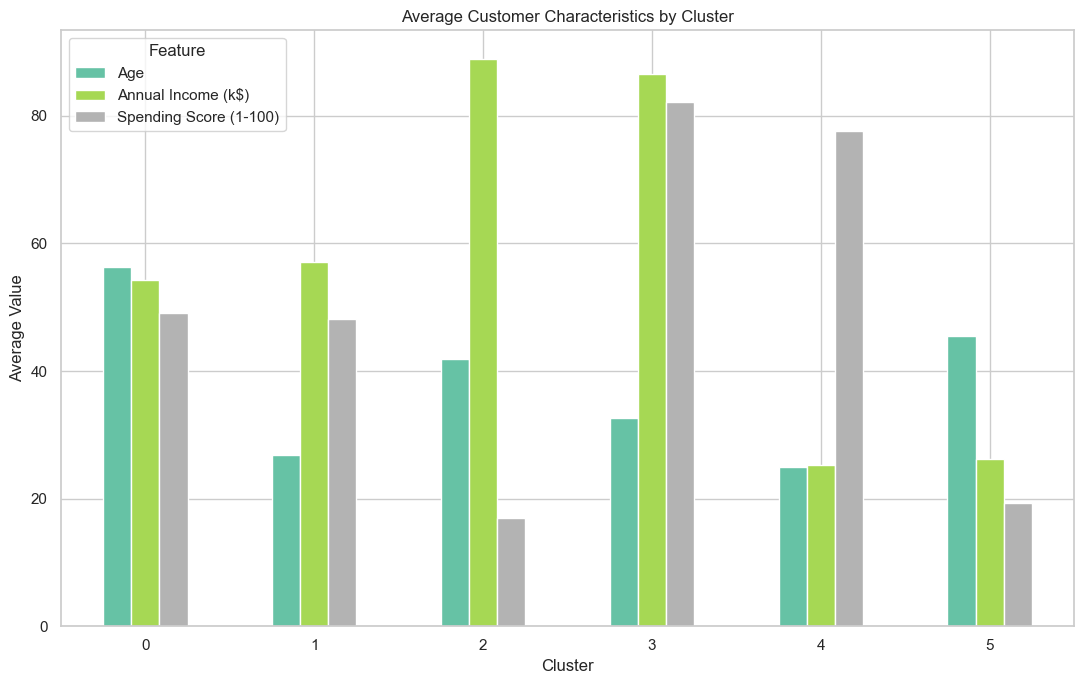


PCA VISUALIZATION

Total variance explained by the first two PCA components: 77.57%


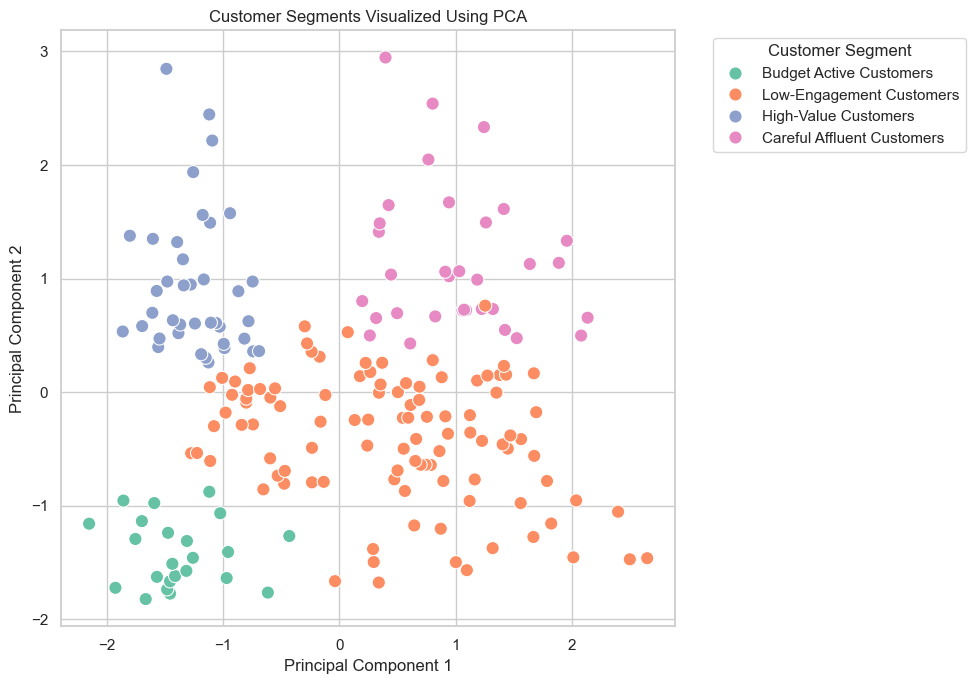


BUSINESS RECOMMENDATIONS

Cluster 0: Low-Engagement Customers
Customer count: 45
Average age: 56.33
Average annual income: 54.27 k$
Average spending score: 49.07
Recommendation: Use low-cost re-engagement campaigns, limited-time offers, or survey feedback.

Cluster 1: Low-Engagement Customers
Customer count: 39
Average age: 26.79
Average annual income: 57.1 k$
Average spending score: 48.13
Recommendation: Use low-cost re-engagement campaigns, limited-time offers, or survey feedback.

Cluster 2: Careful Affluent Customers
Customer count: 33
Average age: 41.94
Average annual income: 88.94 k$
Average spending score: 16.97
Recommendation: Use personalized discounts, product demonstrations, and targeted offers to encourage higher spending.

Cluster 3: High-Value Customers
Customer count: 39
Average age: 32.69
Average annual income: 86.54 k$
Average spending score: 82.13
Recommendation: Offer premium products, VIP benefits, early access, and loyalty rewards.

Cluster 4: Budget Active Custom

In [3]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# -----------------------------
# 1. PROJECT SETTINGS
# -----------------------------
DATA_FILE = "Mall_Customers.csv"
OUTPUT_FOLDER = "outputs"
RANDOM_STATE = 42

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")

# -----------------------------
# 2. LOAD DATA
# -----------------------------
print("\n" + "=" * 60)
print("CUSTOMER SEGMENTATION USING K-MEANS")
print("=" * 60)

# if not os.path.exists(DATA_FILE):
#     raise FileNotFoundError(
#         f"\n'{DATA_FILE}' was not found.\n"
#         "Download the CSV file and place it in the same folder as this script."
#     )

df = pd.read_csv(r"C:\Users\LOKESH\Downloads\Mall_Customers.csv")

print("\nDataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

print("\nFirst five rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
print(df.describe())

# Some versions of this dataset use 'Genre' instead of 'Gender'.
if "Genre" in df.columns:
    df.rename(columns={"Genre": "Gender"}, inplace=True)

# -----------------------------
# 3. DATA CLEANING
# -----------------------------
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

original_rows = len(df)

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

print(f"Rows before cleaning: {original_rows}")
print(f"Rows after cleaning: {len(df)}")
print(f"Duplicate rows removed: {original_rows - len(df)}")

# CustomerID is only an identifier, so it should not be used in K-Means.
if "CustomerID" in df.columns:
    print("\nCustomerID will not be used for clustering because it is only an identifier.")

# Features used for clustering.
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features].copy()

print("\nFeatures selected for clustering:")
print(features)

# -----------------------------
# 4. EXPLORATORY DATA ANALYSIS
# -----------------------------
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Plot 1: Income vs Spending Score
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=80,
    color="steelblue"
)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "income_vs_spending_before_clustering.png"),
    dpi=300
)
plt.show()

# Plot 2: Age distribution
plt.figure(figsize=(9, 6))
sns.histplot(df["Age"], bins=15, kde=True, color="purple")
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "age_distribution.png"),
    dpi=300
)
plt.show()

# Plot 3: Gender distribution, only if gender exists in the dataset.
if "Gender" in df.columns:
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, x="Gender", hue="Gender", legend=False)
    plt.title("Customer Count by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_FOLDER, "gender_distribution.png"),
        dpi=300
    )
    plt.show()

# Pairplot
pairplot = sns.pairplot(
    df[features],
    diag_kind="hist",
    corner=True
)
pairplot.fig.suptitle("Relationships Between Customer Features", y=1.02)
pairplot.savefig(
    os.path.join(OUTPUT_FOLDER, "feature_pairplot.png"),
    dpi=300
)
plt.show()

# -----------------------------
# 5. FEATURE SCALING
# -----------------------------
print("\n" + "=" * 60)
print("FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures were standardized using StandardScaler.")
print("This is important because K-Means uses distance calculations.")

# -----------------------------
# 6. FIND BEST NUMBER OF CLUSTERS
# -----------------------------
print("\n" + "=" * 60)
print("SELECTING THE NUMBER OF CLUSTERS")
print("=" * 60)

k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results_df = pd.DataFrame({
    "Number of Clusters (k)": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

print("\nCluster evaluation results:")
print(results_df.round(4))

results_df.to_csv(
    os.path.join(OUTPUT_FOLDER, "cluster_evaluation_scores.csv"),
    index=False
)

# Plot 4: Elbow method
plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker="o", linewidth=2, color="royalblue")
plt.title("Elbow Method for Selecting Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "elbow_method.png"),
    dpi=300
)
plt.show()

# Plot 5: Silhouette scores
plt.figure(figsize=(9, 6))
plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="seagreen"
)
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "silhouette_scores.png"),
    dpi=300
)
plt.show()

# Choose the k with the highest silhouette score.
best_k = list(k_values)[np.argmax(silhouette_scores)]

print(f"\nBest k based on silhouette score: {best_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

# -----------------------------
# 7. BUILD FINAL K-MEANS MODEL
# -----------------------------
print("\n" + "=" * 60)
print("FINAL K-MEANS MODEL")
print("=" * 60)

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

df["Cluster"] = final_kmeans.fit_predict(X_scaled)

print("\nCustomers assigned to clusters successfully.")

cluster_counts = df["Cluster"].value_counts().sort_index()

print("\nNumber of customers in each cluster:")
print(cluster_counts)

# -----------------------------
# 8. CLUSTER PROFILE ANALYSIS
# -----------------------------
print("\n" + "=" * 60)
print("CLUSTER PROFILE ANALYSIS")
print("=" * 60)

cluster_profile = df.groupby("Cluster")[features].mean().round(2)
cluster_profile["Customer Count"] = cluster_counts
cluster_profile = cluster_profile.sort_index()

print("\nAverage values by cluster:")
print(cluster_profile)

cluster_profile.to_csv(
    os.path.join(OUTPUT_FOLDER, "cluster_profile.csv")
)

# Create meaningful labels from income and spending behavior.
overall_income = df["Annual Income (k$)"].median()
overall_spending = df["Spending Score (1-100)"].median()

def assign_segment_name(row):
    income = row["Annual Income (k$)"]
    spending = row["Spending Score (1-100)"]

    if income >= overall_income and spending >= overall_spending:
        return "High-Value Customers"

    if income >= overall_income and spending < overall_spending:
        return "Careful Affluent Customers"

    if income < overall_income and spending >= overall_spending:
        return "Budget Active Customers"

    return "Low-Engagement Customers"

cluster_profile["Segment Name"] = cluster_profile.apply(
    assign_segment_name,
    axis=1
)

print("\nCluster names and interpretations:")
print(cluster_profile)

cluster_profile.to_csv(
    os.path.join(OUTPUT_FOLDER, "cluster_profile_with_names.csv")
)

# Add the meaningful segment name back to every customer row.
segment_name_mapping = cluster_profile["Segment Name"].to_dict()
df["Segment Name"] = df["Cluster"].map(segment_name_mapping)

# Save final customer data with cluster and segment name.
df.to_csv(
    os.path.join(OUTPUT_FOLDER, "customers_with_clusters.csv"),
    index=False
)

# -----------------------------
# 9. VISUALIZE FINAL CLUSTERS
# -----------------------------
print("\n" + "=" * 60)
print("CLUSTER VISUALIZATIONS")
print("=" * 60)

# Plot 6: Income vs Spending Score clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Segment Name",
    palette="Set2",
    s=90
)

plt.title("Customer Segments: Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "customer_clusters_income_spending.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Plot 7: Age vs Spending Score clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Segment Name",
    palette="Set2",
    s=90
)

plt.title("Customer Segments: Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "customer_clusters_age_spending.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Plot 8: Cluster profile bar chart
profile_for_plot = cluster_profile[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
]

profile_for_plot.plot(
    kind="bar",
    figsize=(11, 7),
    colormap="Set2"
)

plt.title("Average Customer Characteristics by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "cluster_profile_bar_chart.png"),
    dpi=300
)
plt.show()

# -----------------------------
# 10. PCA VISUALIZATION
# -----------------------------
print("\n" + "=" * 60)
print("PCA VISUALIZATION")
print("=" * 60)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Cluster"] = df["Cluster"]
pca_df["Segment Name"] = df["Segment Name"]

explained_variance = pca.explained_variance_ratio_.sum() * 100

print(
    f"\nTotal variance explained by the first two PCA components: "
    f"{explained_variance:.2f}%"
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Segment Name",
    palette="Set2",
    s=90
)

plt.title("Customer Segments Visualized Using PCA")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "customer_clusters_pca.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -----------------------------
# 11. BUSINESS RECOMMENDATIONS
# -----------------------------
print("\n" + "=" * 60)
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

recommendations = {
    "High-Value Customers": (
        "Offer premium products, VIP benefits, early access, and loyalty rewards."
    ),
    "Careful Affluent Customers": (
        "Use personalized discounts, product demonstrations, and targeted offers "
        "to encourage higher spending."
    ),
    "Budget Active Customers": (
        "Offer affordable bundles, discounts, reward points, and value-based promotions."
    ),
    "Low-Engagement Customers": (
        "Use low-cost re-engagement campaigns, limited-time offers, or survey feedback."
    )
}

for cluster_number, row in cluster_profile.iterrows():
    segment = row["Segment Name"]

    print(f"\nCluster {cluster_number}: {segment}")
    print(f"Customer count: {int(row['Customer Count'])}")
    print(f"Average age: {row['Age']}")
    print(f"Average annual income: {row['Annual Income (k$)']} k$")
    print(f"Average spending score: {row['Spending Score (1-100)']}")
    print(f"Recommendation: {recommendations[segment]}")

# -----------------------------
# 12. FINAL SUMMARY
# -----------------------------
print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"\nFinal number of clusters selected: {best_k}")
print(f"Final silhouette score: {max(silhouette_scores):.4f}")

print("\nFiles created inside the 'outputs' folder:")
print("- cluster_evaluation_scores.csv")
print("- cluster_profile.csv")
print("- cluster_profile_with_names.csv")
print("- customers_with_clusters.csv")
print("- age_distribution.png")
print("- gender_distribution.png (if Gender column exists)")
print("- feature_pairplot.png")
print("- income_vs_spending_before_clustering.png")
print("- elbow_method.png")
print("- silhouette_scores.png")
print("- customer_clusters_income_spending.png")
print("- customer_clusters_age_spending.png")
print("- cluster_profile_bar_chart.png")
print("- customer_clusters_pca.png")